In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR

In this file, we clean both futures data and AI agent data, and store the result in the "data_2" folder.

Code before the "Function" section does not modify any files.

After calling the functions in the "Function" section, cleaned futures data, cleaned agent data, resampled futures data will be saved to the "data_2" foler.

# **Futures Data**

### **Step 1: Remove illiquid periods**

The goal is to identify and keep only the liquid trading period of each contract.

**Initial approach (volume threshold)**

A natural idea is to filter based on volume:

- compute the maximum per-minute volume

- find the first timestamp where volume exceeds 10% of the maximum

- keep the data after this point as the liquid period

This works well for most assets, but fails for Heating Oil, confirming the irregular behavior observed earlier.

All Markets: ['Nasdaq', 'German Bunds - German Government Bonds', 'EuroStoxx', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'GBP - British Pound']
Number of markets: 7
Nasdaq: 3 data files
Nasdaq: ['NQH20.csv', 'NQU20.csv', 'NQM20.csv']


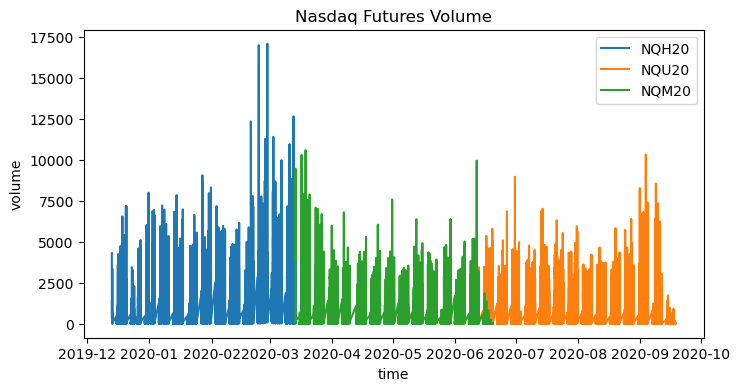

German Bunds - German Government Bonds: 3 data files
German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']


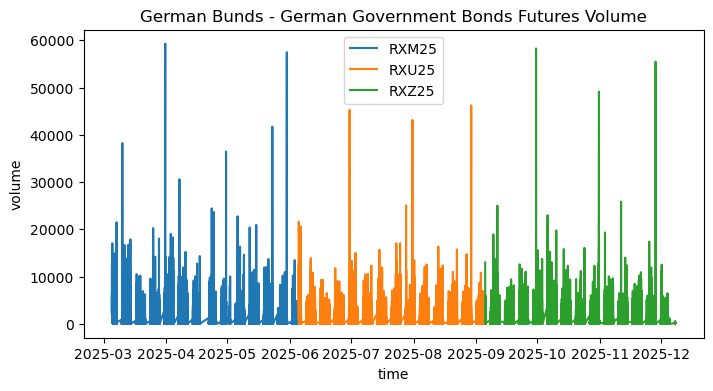

EuroStoxx: 2 data files
EuroStoxx: ['VGM22.csv', 'VGH22.csv']


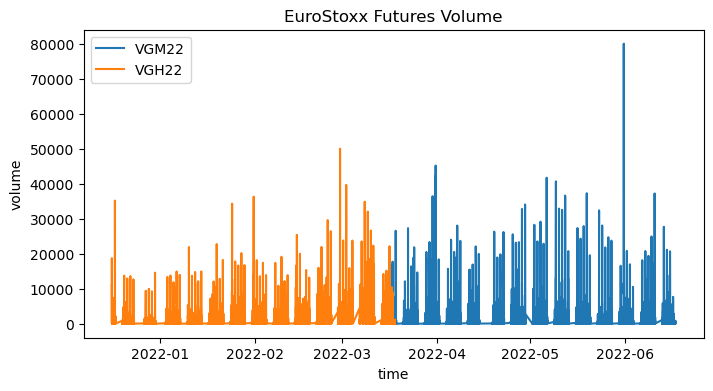

Gold: 4 data files
Gold: ['GCG24.csv', 'GCM24.csv', 'GCQ24.csv', 'GCJ24.csv']


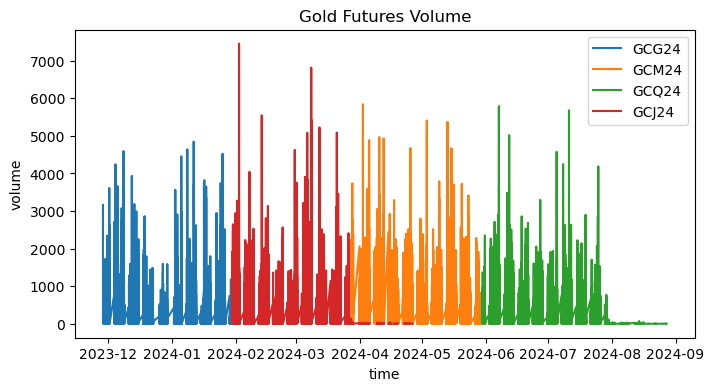

HeatingOil: 7 data files
HeatingOil: ['HOM22.csv', 'HOK22.csv', 'HON22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOF22.csv', 'HOG22.csv']


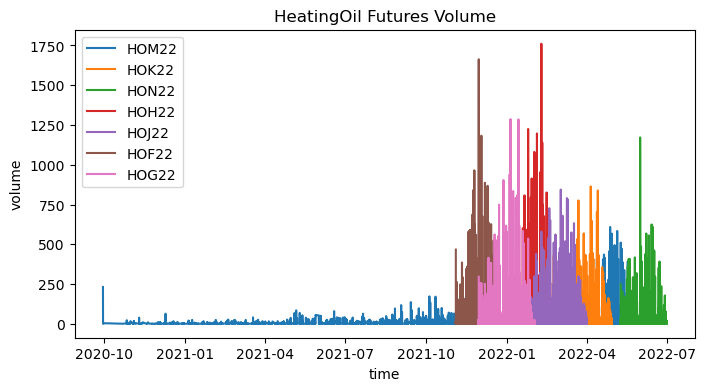

JPY - Japanese Yen: 2 data files
JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']


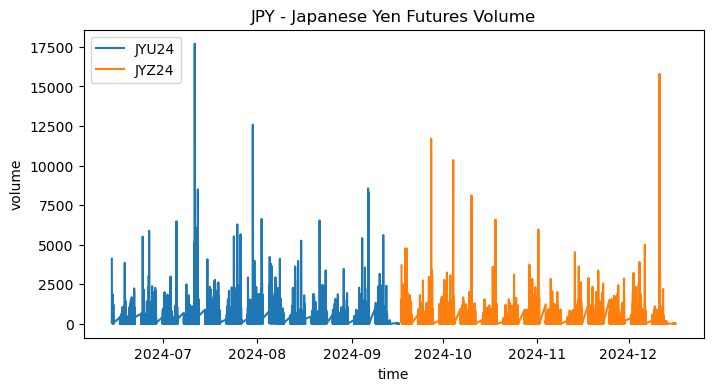

GBP - British Pound: 2 data files
GBP - British Pound: ['BPM20.csv', 'BPU20.csv']


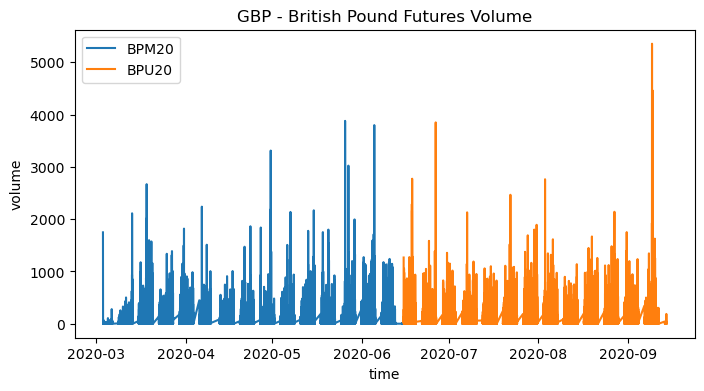

In [25]:
def plot_volume(raw_data_path:Path):
    markets=[p.name for p in raw_data_path.iterdir() if p.is_dir()]
    print(f'All Markets: {markets}')
    print(f'Number of markets: {len(markets)}')
    
    for market in markets:
        market_path=raw_data_path/market
        files=[ p.name for p in market_path.glob("*.csv")
               if not p.name.startswith("AIAgent")]
        print(f'{market}: {len(files)} data files')
        print(f'{market}: {files}')
        
        volume_df=[]
        for file in files:
            data=pd.read_csv(market_path/file,header=None)
            data.columns=['time','open','high','low','close','volume']
            data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
            data['time']=pd.to_datetime(data['time'])
            data.set_index('time',inplace=True)
            
            max_volume=data['volume'].max()
            start_time=data[data['volume']>max_volume*0.2].index[0]
            data=data.loc[start_time:]
            data=data['volume']
            data.name=file[:-4]
            volume_df.append(data)
            
        volume_df=pd.concat(volume_df,axis=1,join='outer')
        
        plt.figure(figsize=(8,4))
        for f in volume_df.columns:
            plt.plot(volume_df.index,volume_df[f],label=f)
        plt.xlabel('time')
        plt.ylabel('volume')
        plt.title(f'{market} Futures Volume')
        plt.legend()
        plt.show()
            
plot_volume(RAW_DATA_DIR)

**Improved approach (daily aggregation)**

Minute-level data is noisy. We instead switch to daily-level statistics:

- Resample to daily volume

- count number of observations per day

- define trading coverage ratio
$$
\text{coverage}=\frac{\text{\# observations}}{1380}
$$
since futures trade 23 hours -> 1380 minutes

We also shift timestamps by +6 hours to align with the trading day (0:00-23:00), which simplifies grouping.

**Two filtering methods**

We compare two approaches:

1. **volume threshold (chosen method)**

- find first date where daily volume exceeds 10% of max daily volume

- keep data after this date

- works robustly across all assets, including Heating Oil

2. **Coverage ratio (rejected)**

- keep days with coverage >= 90% (as suggested in the PDF)

- fails for some assets(Euro, German bond, Heating Oil), which seldom reach 90% even during liquid periods

- First resample the volume series into daily volume, at the same time, calculate how many rows are there in each trading day.

So, we use volume-based method.

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
EuroStoxx: 2 data files
EuroStoxx: ['VGH22.csv', 'VGM22.csv']


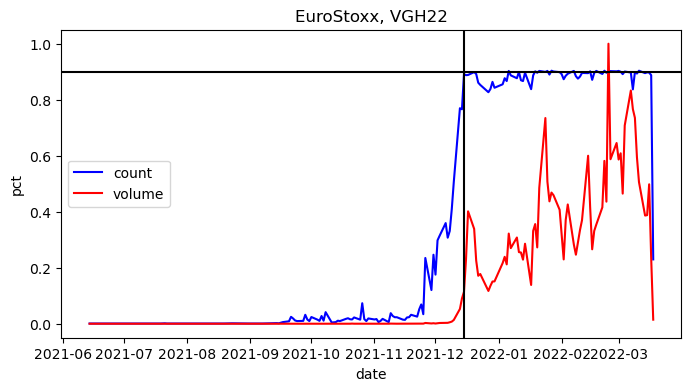

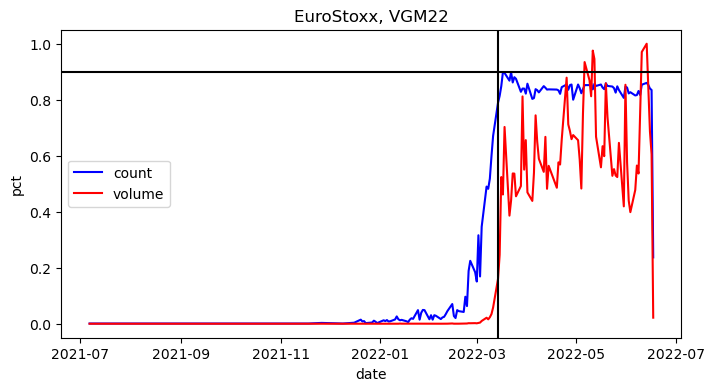

GBP - British Pound: 2 data files
GBP - British Pound: ['BPM20.csv', 'BPU20.csv']


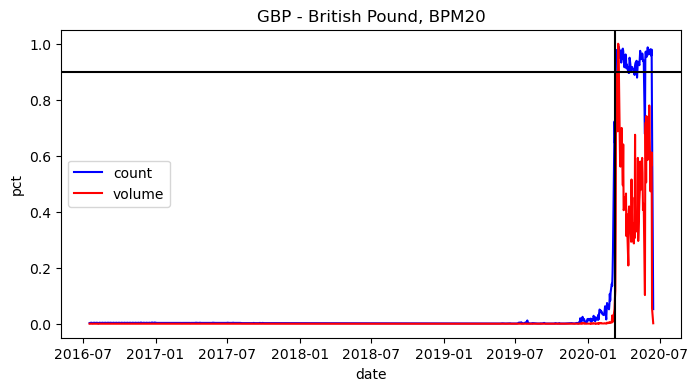

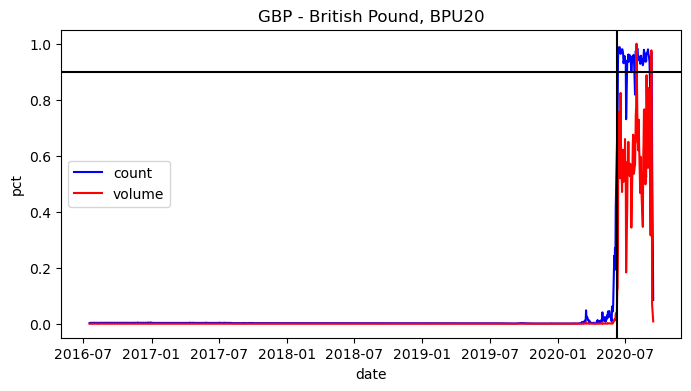

German Bunds - German Government Bonds: 3 data files
German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']


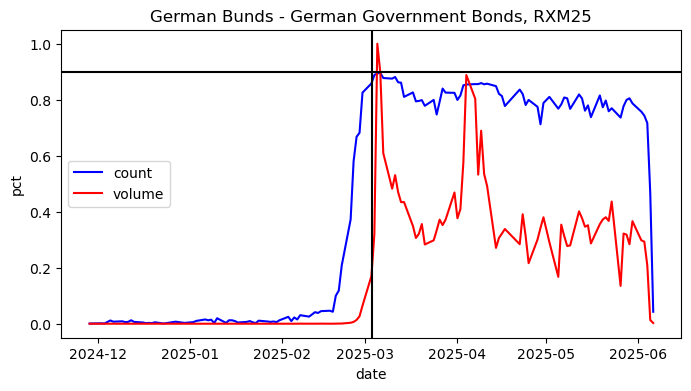

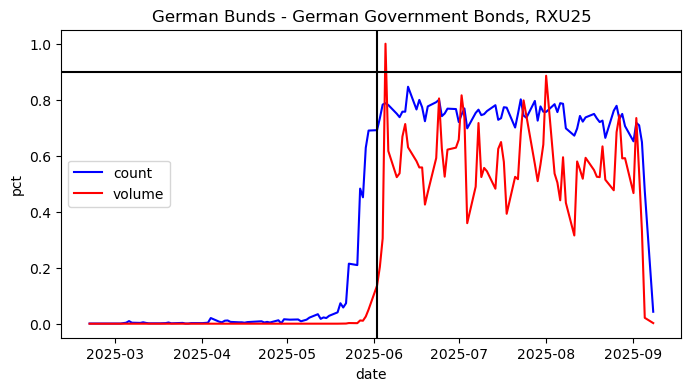

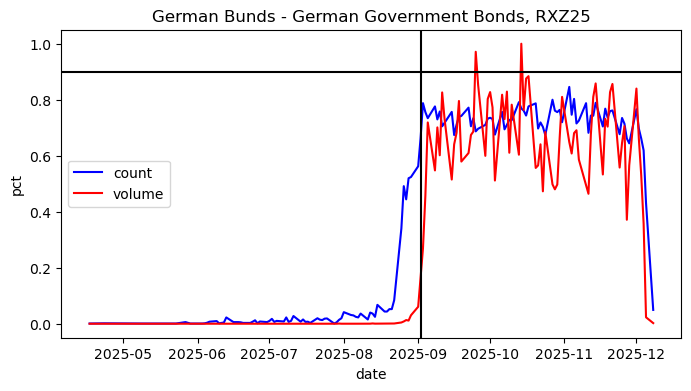

Gold: 4 data files
Gold: ['GCG24.csv', 'GCJ24.csv', 'GCM24.csv', 'GCQ24.csv']


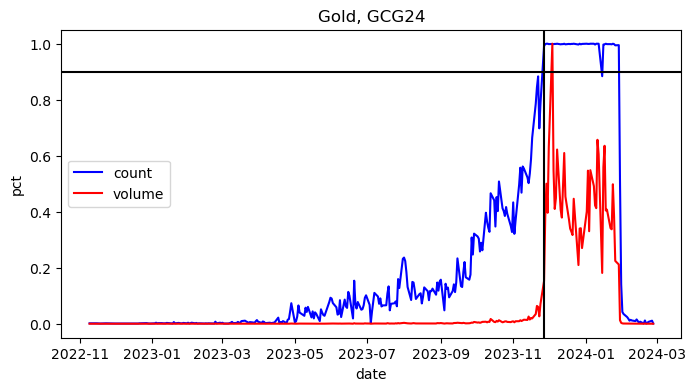

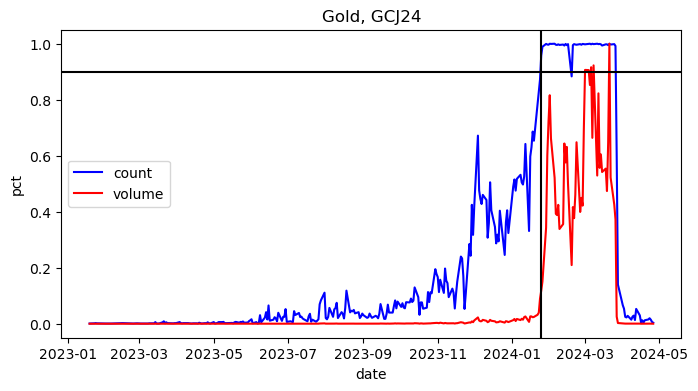

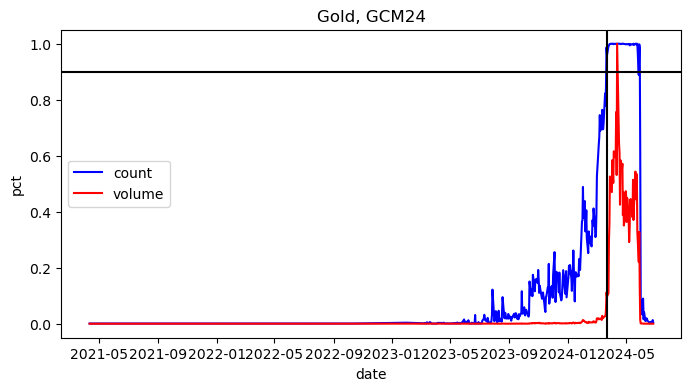

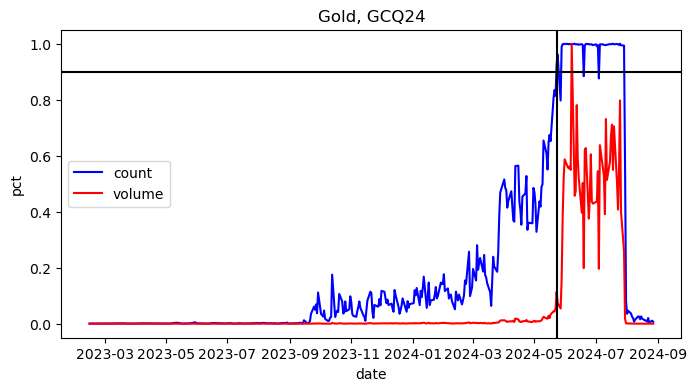

HeatingOil: 7 data files
HeatingOil: ['HOF22.csv', 'HOG22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOK22.csv', 'HOM22.csv', 'HON22.csv']


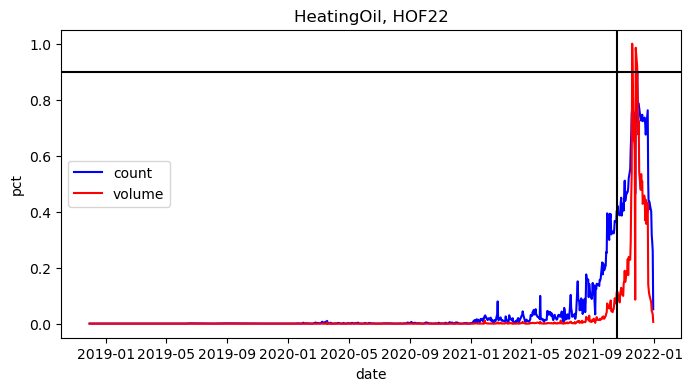

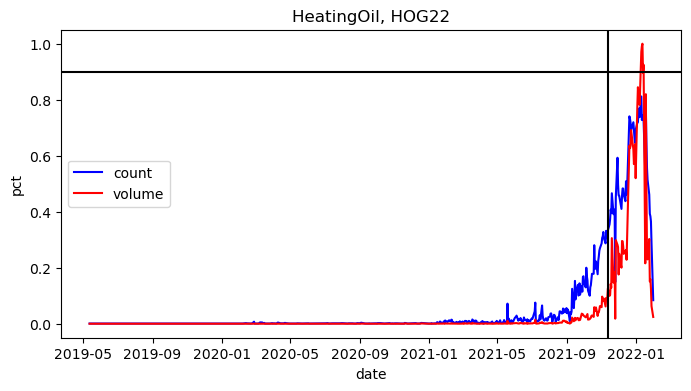

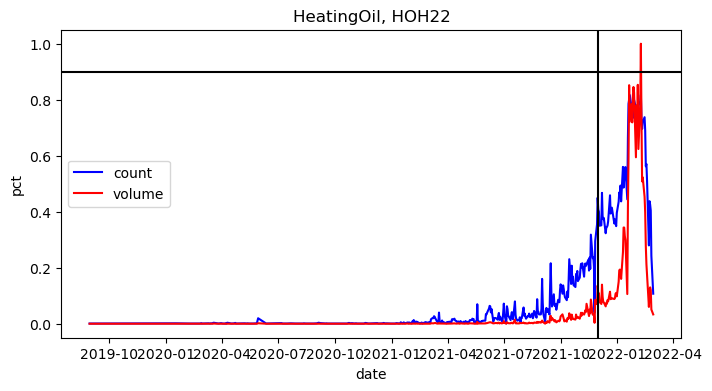

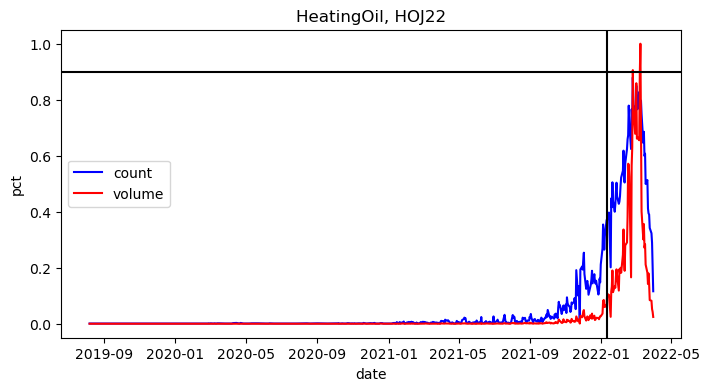

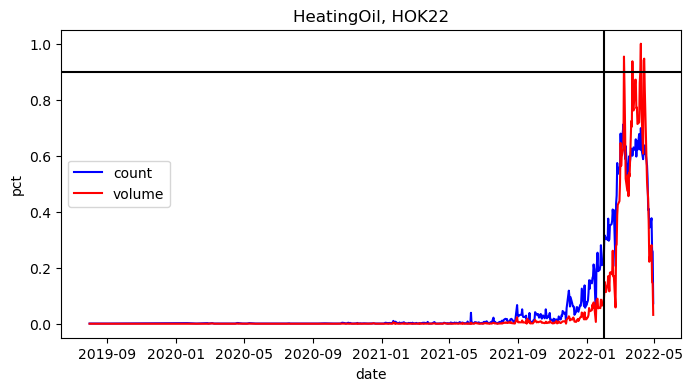

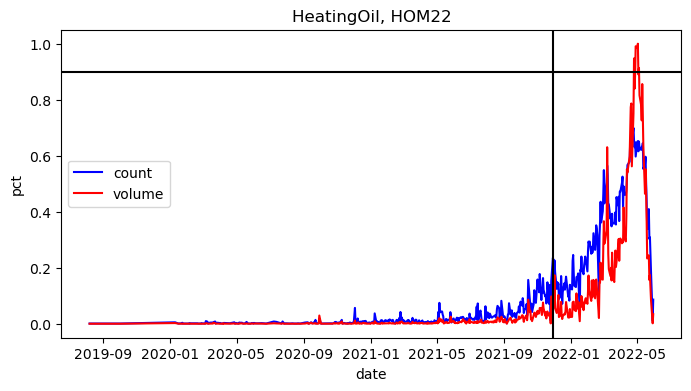

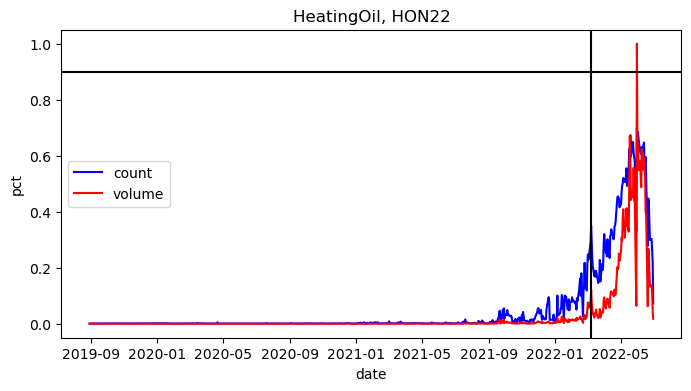

JPY - Japanese Yen: 2 data files
JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']


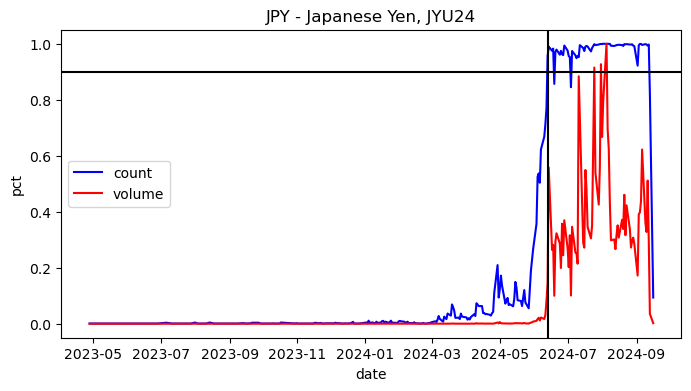

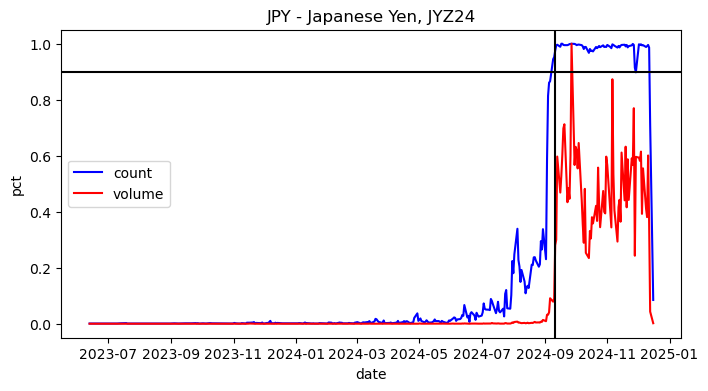

Nasdaq: 3 data files
Nasdaq: ['NQH20.csv', 'NQM20.csv', 'NQU20.csv']


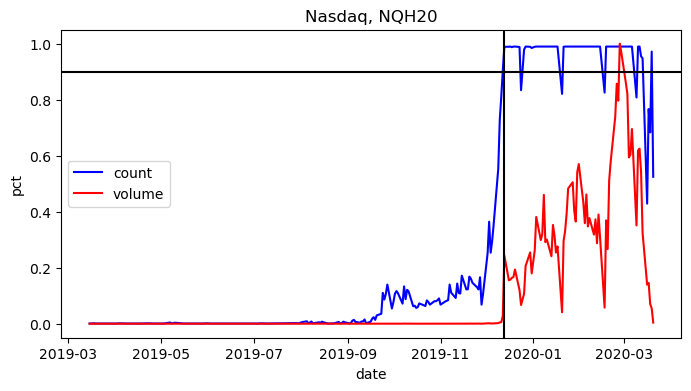

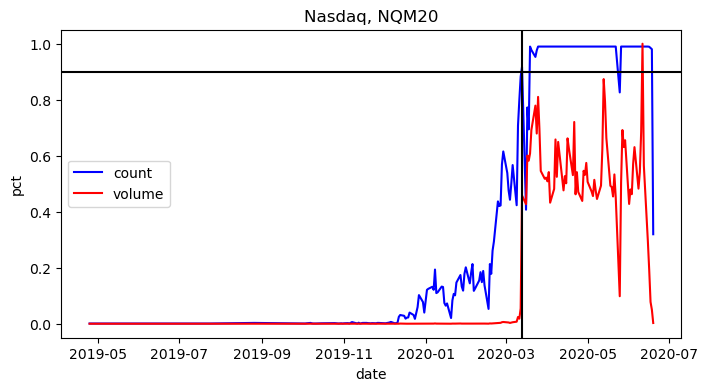

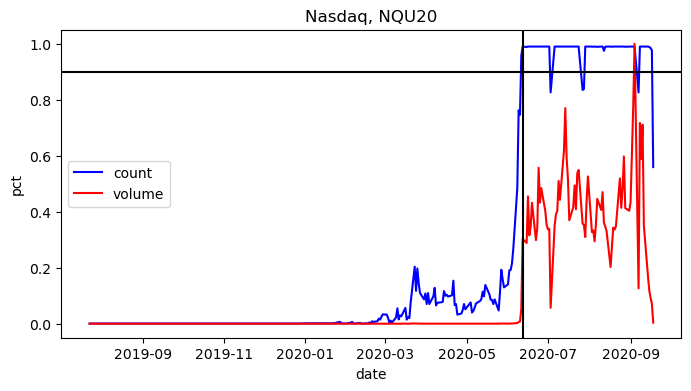

In [2]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
print(f'All Markets: {markets}')
print(f'Number of markets: {len(markets)}')

for market in markets:
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    print(f'{market}: {len(files)} data files')
    print(f'{market}: {files}')
    
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file)
        data.columns=['time','open','high','low','close','volume']
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])

        data['time']=data['time']+pd.Timedelta(hours=6)
        data['date']=data['time'].dt.date
        data.set_index('time',inplace=True)

        # max_volume=data['volume'].max()
        # start_time=data[data['volume']>max_volume*0.2].index[0]
        
        count_series=data.groupby('date')['volume'].count()/float(23*60)
        max_series=data.groupby('date')['volume'].sum()
        max_series=max_series/max_series.max()
        start_date=max_series[max_series>0.1].index[0]
        start_time=data.loc[start_date:].index[0]

        plt.figure(figsize=(8,4))
        plt.plot(count_series.index,count_series.values,color='blue',label='count')
        plt.plot(max_series.index,max_series.values,color='red',label='volume')
        plt.axvline(start_time,color='black')
        plt.axhline(0.9,color='black')
        plt.xlabel('date')
        plt.ylabel('pct')
        plt.title(f'{market}, {file[:-4]}')
        plt.legend()
        plt.show()
                

### **Step 2: Construct continuoous contract**

We now combine contracts into a continuous series.

- work at the daily level (to avoid noisy switching)

- for each day, select the contract with the highest volume

- this defines the front contract

This method produces a clean "staircase" pattern with no back-and-forth switching.

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
EuroStoxx: 2 data files
EuroStoxx: ['VGH22.csv', 'VGM22.csv']


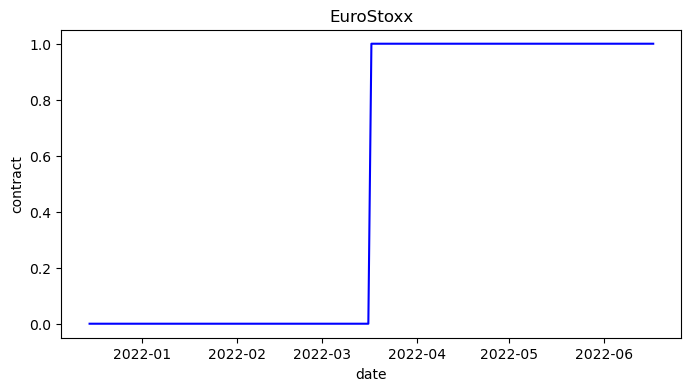

GBP - British Pound: 2 data files
GBP - British Pound: ['BPM20.csv', 'BPU20.csv']


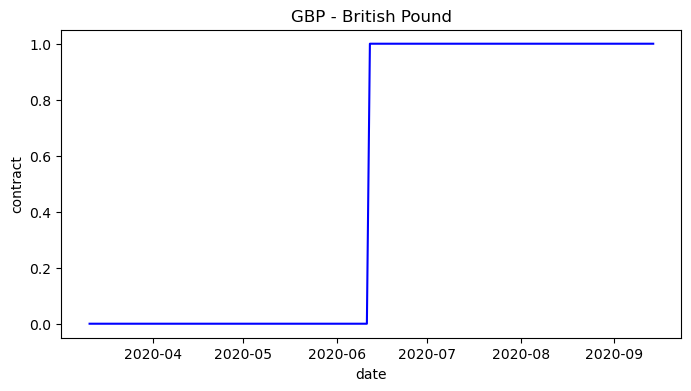

German Bunds - German Government Bonds: 3 data files
German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']


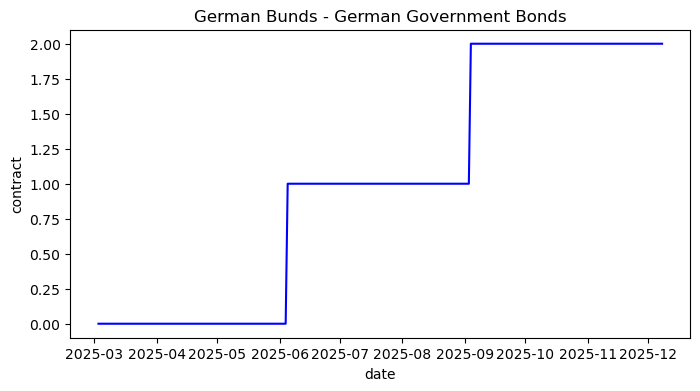

Gold: 4 data files
Gold: ['GCG24.csv', 'GCJ24.csv', 'GCM24.csv', 'GCQ24.csv']


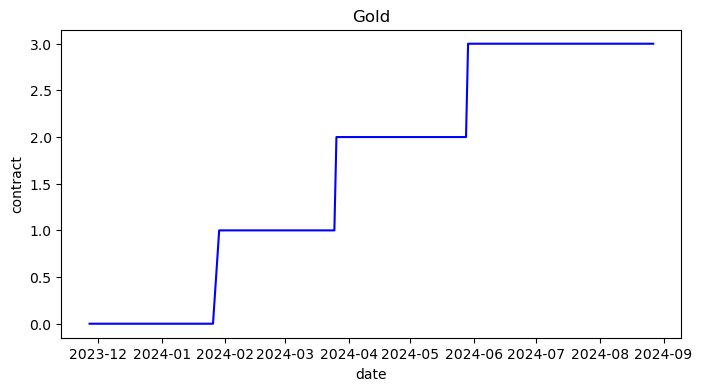

HeatingOil: 7 data files
HeatingOil: ['HOF22.csv', 'HOG22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOK22.csv', 'HOM22.csv', 'HON22.csv']


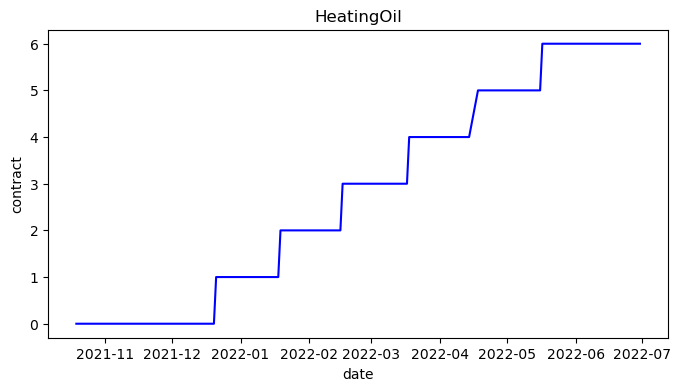

JPY - Japanese Yen: 2 data files
JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']


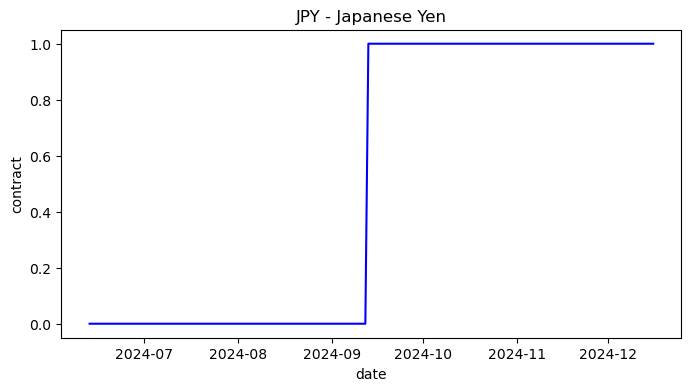

Nasdaq: 3 data files
Nasdaq: ['NQH20.csv', 'NQM20.csv', 'NQU20.csv']


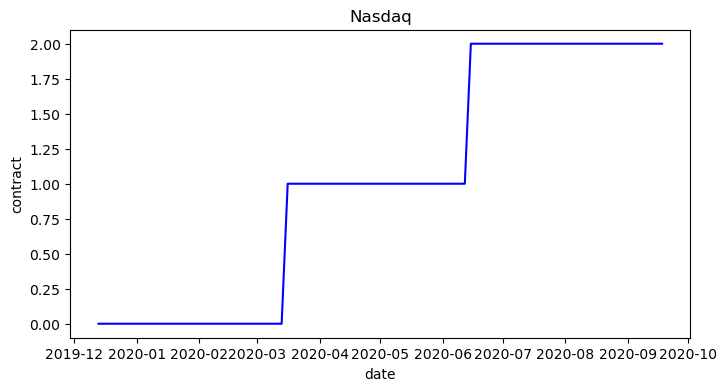

In [ ]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
print(f'All Markets: {markets}')
print(f'Number of markets: {len(markets)}')

for market in markets:
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    print(f'{market}: {len(files)} data files')
    print(f'{market}: {files}')
    
    volume_series_list=[]
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file)
        data.columns=['time','open','high','low','close','volume']
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])

        data['time']=data['time']+pd.Timedelta(hours=6)
        data['date']=data['time'].dt.date
        data.set_index('time',inplace=True)
        
        max_series=data.groupby('date')['volume'].sum()
        max_series=max_series/max_series.max()
        start_date=max_series[max_series>0.1].index[0]
        data=data.loc[start_date:]
        
        volume_series=data.groupby('date')['volume'].sum().dropna()
        volume_series.name=file[:-4]
        volume_series_list.append(volume_series)
        
    volume_df=pd.concat(volume_series_list,axis=1,join='outer')
    volume_df['contract']=np.nanargmax(volume_df.values,axis=1)
        

    plt.figure(figsize=(8,4))
    plt.plot(volume_df.index,volume_df['contract'].values,color='blue')
    plt.xlabel('date')
    plt.ylabel('contract')
    plt.title(f'{market}')
    plt.show()
                

### **Final cleaned data**

The cleaned futures data is stored in RAW_DATA_DIR/'futures'/'minute_1'.

Each file contains 8 columns:
$$
[\text{time, open, high, low, close, volume, date, contract}]
$$
where contract indicates which contract the data comes from.

Notes:

- We don't remove the illiquid tail of the final contract (no alternative contract exists)

- Data is aligned with AI agent timestamps; excess data is trimmed if necessary

- Some inconsistence exist: JPY and GBP's agent data extend beyond futures data

In [30]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
print(f'All Markets: {markets}')
print(f'Number of markets: {len(markets)}')

market_dict={}
fields=['open', 'high', 'low', 'close', 'volume']


for market in markets:
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
             if p.name.startswith("AIAgent")][0]
    print(f'{market}: {len(files)} data files')
    print(f'{market}: {files}')
    
    volume_series_list=[]
    data_dict={c: [] for c in fields}
    
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
        data=data.dropna() # delete rows with missing value
        data.columns=['time','open','high','low','close','volume']
        data=data.sort_values('time')
        data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
        data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=6) # change from calendar days to trading days
        data['date']=data['time'].dt.date
        data.set_index('time',inplace=True)
        
        # delete low volume period (beginning period)
        daily_volume=data.groupby('date')['volume'].sum()
        daily_volume_norm=daily_volume/daily_volume.max()
        valid_dates=daily_volume_norm[daily_volume_norm>0.1]
        if len(valid_dates)==0:
            print(f'Warning: {market}, {file}, no valid dates')
            continue
        start_date=pd.Timestamp(valid_dates.index[0])
        data=data.loc[data.index>=start_date]
        
        for c in fields:
            series=data[c].copy()
            series.name=file[:-4]
            data_dict[c].append(series)
        
        daily_volume=data.groupby('date')['volume'].sum()
        daily_volume.name=file[:-4]
        volume_series_list.append(daily_volume)
        
    if len(volume_series_list)==0:
        print(f'Warning: {market}, daily volume series list is empty.')
        continue
    
    # decide the rolling
    volume_df=pd.concat(volume_series_list,axis=1,join='outer').sort_index()
    volume_df=volume_df.reindex(sorted(volume_df.columns),axis=1)
    contract_cols = list(volume_df.columns)  # important, contract names sorted by expiration month
    volume_df=volume_df.dropna(how='all')
    volume_df['contract']=np.nanargmax(volume_df.values,axis=1)
    volume_df.reset_index(inplace=True)

    for c in fields:
        df=pd.concat(data_dict[c],axis=1,join='outer')
        df=df.reset_index()
        df['date']=df['time'].dt.date
        df=df.merge(volume_df[['date','contract']],on='date',how='inner')
        df=df.set_index('time')
        
        values = df[contract_cols].to_numpy()
        row_idx = np.arange(len(df))
        col_idx = df['contract'].to_numpy()
        df[c] = values[row_idx, col_idx]
        data_dict[c] = df[c]
        
    combined_df=pd.DataFrame.from_dict(data_dict)
    combined_df.reset_index(inplace=True)
    combined_df['date']=combined_df['time'].dt.date
    combined_df=combined_df.merge(volume_df[['date','contract']],on='date',how='inner')
    
    market_dict[market]=combined_df
    
    ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    ai_data.columns=['date','hour','minute','price','position']
    ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
    ai_data['time'] = (ai_data['date']
                       + pd.to_timedelta(ai_data['hour'], unit='h') 
                       + pd.to_timedelta(ai_data['minute'], unit='m'))
    ai_data['time']=ai_data['time']+pd.Timedelta(hours=6)
    ai_data=ai_data.sort_values('time')
    
    start_days=(pd.Timestamp(combined_df['date'].iloc[0])-ai_data['date'].iloc[0]).days
    end_days=(pd.Timestamp(combined_df['date'].iloc[-1])-ai_data['date'].iloc[-1]).days
    
    print(f'{market} start days: {start_days}')
    print(f'{market} end days: {end_days}')      
    
market_dict[market].head()

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
EuroStoxx: 2 data files
EuroStoxx: ['VGH22.csv', 'VGM22.csv']
EuroStoxx start days: -18
EuroStoxx end days: 17
GBP - British Pound: 2 data files
GBP - British Pound: ['BPM20.csv', 'BPU20.csv']
GBP - British Pound start days: -83
GBP - British Pound end days: -16
German Bunds - German Government Bonds: 3 data files
German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']
German Bunds - German Government Bonds start days: -91
German Bunds - German Government Bonds end days: 40
Gold: 4 data files
Gold: ['GCG24.csv', 'GCJ24.csv', 'GCM24.csv', 'GCQ24.csv']
Gold start days: -36
Gold end days: 88
HeatingOil: 7 data files
HeatingOil: ['HOF22.csv', 'HOG22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOK22.csv', 'HOM22.csv', 'HON22.csv']
HeatingOil start days: -134
HeatingOil end days: 0
JPY - Japanese Yen: 2 data files


,time,open,high,low,close,volume,date,contract
0,2019-12-13 00:00:00,8508.00,8521.50,8508.00,8517.50,297.0,2019-12-13,0
1,2019-12-13 00:01:00,8517.50,8518.50,8516.25,8518.00,116.0,2019-12-13,0
2,2019-12-13 00:02:00,8518.25,8518.25,8515.75,8516.75,102.0,2019-12-13,0
3,2019-12-13 00:03:00,8516.75,8519.25,8516.75,8517.75,65.0,2019-12-13,0
4,2019-12-13 00:04:00,8518.75,8518.75,8517.50,8518.00,45.0,2019-12-13,0


In [21]:
print('======== JPY ========')
JPY_ai=pd.read_csv(RAW_DATA_DIR/'JPY - Japanese Yen'/'AIAgent_JPY.csv',header=None)
JPY_data=pd.read_csv(RAW_DATA_DIR/'JPY - Japanese Yen'/'JYZ24.csv',header=None)
JPY_ai.columns=['date','hour','minute','price','position']
JPY_ai['date']=pd.to_datetime(JPY_ai['date'], unit='D', origin='1899-12-30')
JPY_data.columns=['time','open','high','low','close','volume']
JPY_data['time']=pd.to_datetime(JPY_data['time'])
JPY_data['date']=JPY_data['time'].dt.date
JPY_df=market_dict['JPY - Japanese Yen']
print(f'ai last date: {pd.Timestamp(JPY_ai['date'].iloc[-1])}')
print(f'raw last date: {pd.Timestamp(JPY_data['date'].iloc[-1])}')
print(f'combined last date: {pd.Timestamp(JPY_df['date'].iloc[-1])}')

print('======== GBP ========')
GBP_ai=pd.read_csv(RAW_DATA_DIR/'GBP - British Pound'/'AIAgent_GBPUSD.csv',header=None)
GBP_data=pd.read_csv(RAW_DATA_DIR/'GBP - British Pound'/'BPU20.csv',header=None)
GBP_ai.columns=['date','hour','minute','price','position']
GBP_ai['date']=pd.to_datetime(GBP_ai['date'], unit='D', origin='1899-12-30')
GBP_data.columns=['time','open','high','low','close','volume']
GBP_data['time']=pd.to_datetime(GBP_data['time'])
GBP_data['date']=GBP_data['time'].dt.date
GBP_df=market_dict['GBP - British Pound']
print(f'ai last date: {pd.Timestamp(GBP_ai['date'].iloc[-1])}')
print(f'raw last date: {pd.Timestamp(GBP_data['date'].iloc[-1])}')
print(f'combined last date: {pd.Timestamp(GBP_df['date'].iloc[-1])}')

======== JPY ========
ai last date: 2024-12-29 00:00:00
raw last date: 2024-12-16 00:00:00
combined last date: 2024-12-16 00:00:00
======== GBP ========
ai last date: 2020-09-30 00:00:00
raw last date: 2020-09-14 00:00:00
combined last date: 2020-09-14 00:00:00


The cleaned futures data is illusrated in the plots below:

- the volume represents the continous contract volume

- different background colors indicate which underlying contract the data comes from

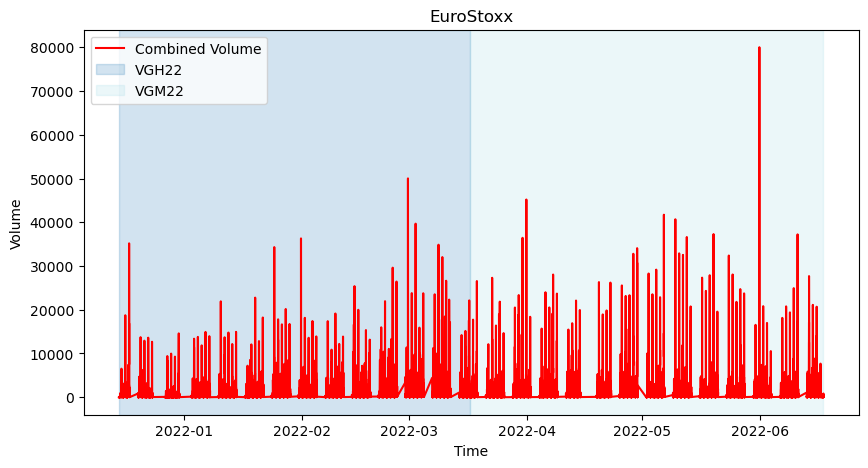

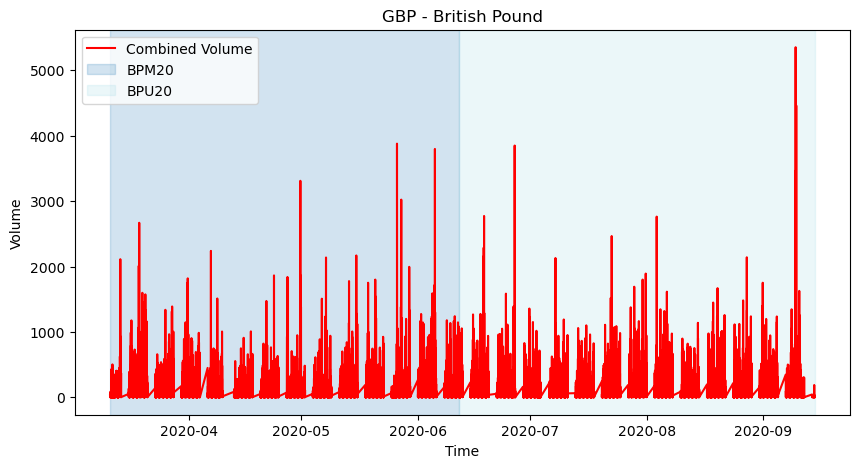

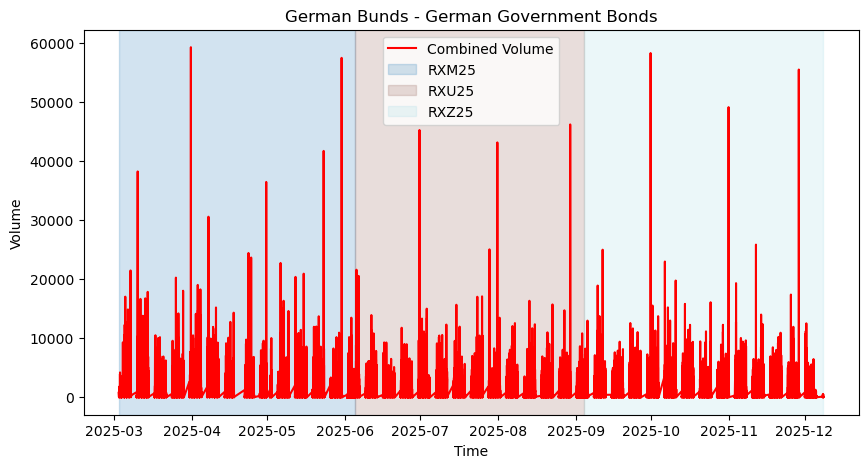

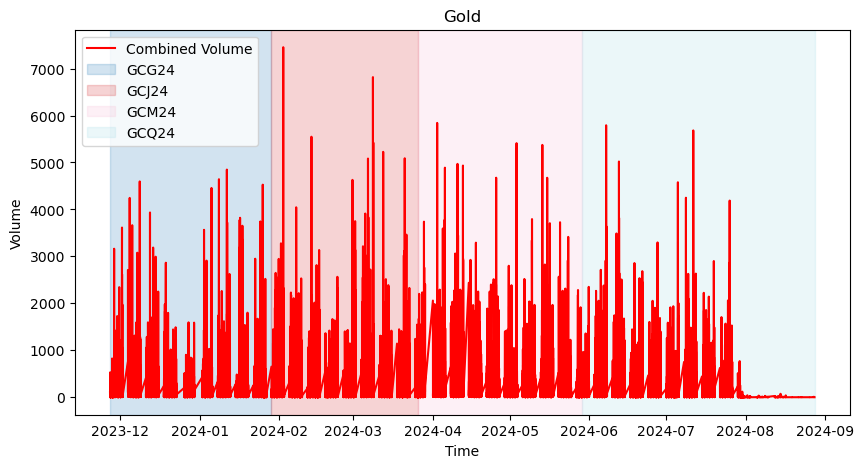

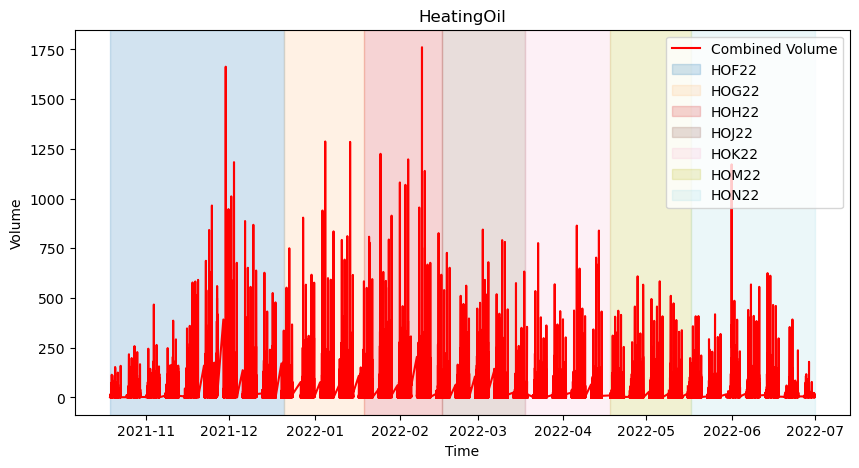

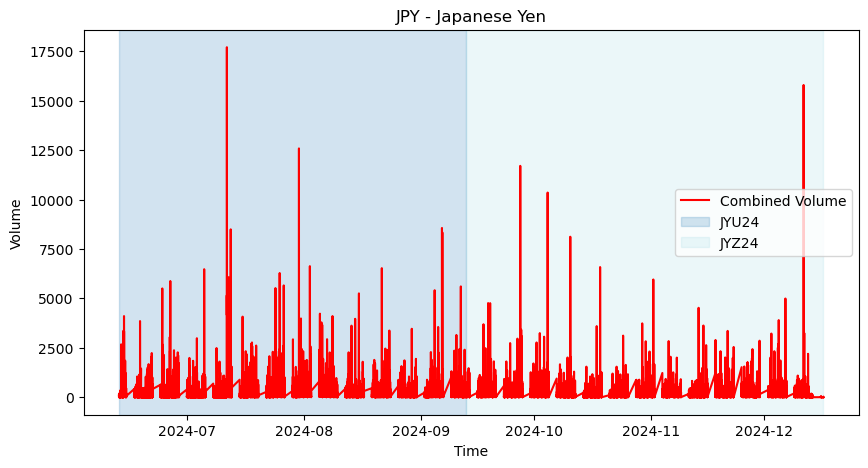

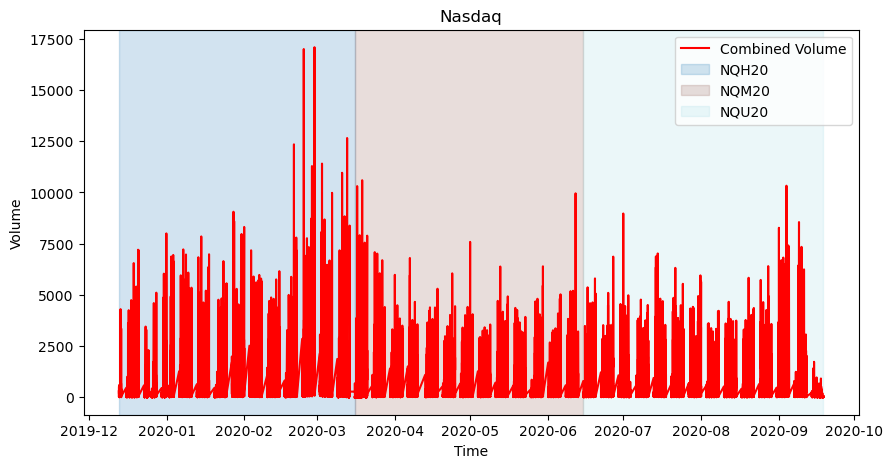

In [24]:
for market,df in market_dict.items():
    
    market_path=RAW_DATA_DIR/market
    files=sorted([p.name for p in market_path.glob("*.csv")
                  if not p.name.startswith("AIAgent")])
    contract_list=[f[:-4] for f in files]
    
    df_plot=df.copy()
    df_plot=df_plot.sort_values('time')
    df_plot.set_index('time',inplace=True)
    vol=df_plot['volume']  # volume series
    contract=df_plot['contract'] # contract series
    
    plt.figure(figsize=(10,5))
    plt.plot(vol.index,vol.values,color='red',label='Combined Volume')

    unique_contracts=np.unique(contract.dropna())
    colors=plt.cm.tab20(np.linspace(0,1,len(unique_contracts)))
    added_labels=set()
    
    for i,c_val in enumerate(unique_contracts):
        mask=(contract==c_val)
        start=None
        
        for t,m in zip(contract.index,mask):
            if m and start is None:
                start=t
            elif not m and start is not None:
                label=contract_list[int(c_val)]
                plt.axvspan(start,t,color=colors[i],alpha=0.2,label=label)
                added_labels.add(label)
                start=None
                
        # handle last segment
        if start is not None:
            label=contract_list[int(c_val)]
            plt.axvspan(start, contract.index[-1], color=colors[i], alpha=0.2,label=label)
            added_labels.add(label)

    plt.title(f"{market}")
    plt.xlabel("Time")
    plt.ylabel("Volume")
    plt.legend()
    plt.show()

# **AI Agent Data**

Minimal preprocessing is applied:

- rename columns

- convert calendar time t traing time (same +6 hours shift)

Each file contains 6 columns:
$$
[\text{date, hour, minute, price, position,time}]
$$

In [32]:
market='Nasdaq'

data=pd.read_parquet(DATA_DIR/'agent'/f'{market}.parquet')
data.head()

,date,hour,minute,price,position,time
0,2020-01-02,0,0,8787.75,0,2020-01-02 06:00:00
1,2020-01-02,0,5,8787.75,0,2020-01-02 06:05:00
2,2020-01-02,0,10,8786.00,0,2020-01-02 06:10:00
3,2020-01-02,0,15,8785.50,0,2020-01-02 06:15:00
4,2020-01-02,0,20,8785.25,0,2020-01-02 06:20:00


# **Resample Futures Data**

Futures data is 1-minuute, while agent data is 5-minute, so we resample.

We implement a generic function for x-minute aggregation (x divides 60).

For each interval:

- open: first price

- close: last price

- high: max

- low: min

- volume: sum

- n_rows: trading coverage ratio

In [29]:
market='Nasdaq'
data=pd.read_parquet(DATA_DIR/'futures'/'minute_1'/f'{market}.parquet')
data.set_index('time',inplace=True)

data['ones']=1
data_5min=data.resample('5min',label='left',closed='left').agg({
    'open':'first',
    'high':'max',
    'low':'min',
    'close':'last',
    'volume':'sum',
    'date':'first',
    'contract':'first',
    'ones': 'sum'
}).rename(columns={'ones': 'n_rows'}).dropna(subset=['open', 'high', 'low', 'close']).reset_index()

data_5min['contract']=data_5min['contract'].astype(int)
data_5min['n_rows']=data_5min['n_rows']/float(5)
data_5min.head()

,time,open,high,low,close,volume,date,contract,n_rows
0,2019-12-13 00:00:00,8508.00,8521.50,8508.00,8518.00,625.0,2019-12-13,0,1.0
1,2019-12-13 00:05:00,8517.50,8524.25,8517.50,8522.75,680.0,2019-12-13,0,1.0
2,2019-12-13 00:10:00,8522.50,8523.25,8521.00,8521.50,163.0,2019-12-13,0,1.0
3,2019-12-13 00:15:00,8521.25,8521.25,8517.50,8518.50,322.0,2019-12-13,0,1.0
4,2019-12-13 00:20:00,8519.00,8521.50,8517.75,8518.25,181.0,2019-12-13,0,1.0


# **Functions**

In [40]:
# 1. clean futures data

def clean_data(
    raw_data_path: Path,
    output_path:Path
)->None:

    markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
    print(f'All Markets: {markets}')
    print(f'Number of markets: {len(markets)}')

    fields=['open', 'high', 'low', 'close', 'volume']


    for market in markets:
        market_path=raw_data_path/market
        files=sorted([p.name for p in market_path.glob("*.csv")
                    if not p.name.startswith("AIAgent")])
        print(f'{market}: {len(files)} data files')
        print(f'{market}: {files}')
        
        volume_series_list=[]
        data_dict={c: [] for c in fields}
        
        for file in files:
            data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
            data=data.dropna() # delete rows with missing value
            data.columns=['time','open','high','low','close','volume']
            data=data.sort_values('time')
            data[['open','high','low','close','volume']]=data[['open','high','low','close','volume']].astype(float)
            data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=6) # change from calendar days to trading days
            data['date']=data['time'].dt.date
            data.set_index('time',inplace=True)
            
            # delete low volume period (beginning period)
            daily_volume=data.groupby('date')['volume'].sum()
            daily_volume_norm=daily_volume/daily_volume.max()
            valid_dates=daily_volume_norm[daily_volume_norm>0.1]
            if len(valid_dates)==0:
                print(f'Warning: {market}, {file}, no valid dates')
                continue
            start_date=pd.Timestamp(valid_dates.index[0])
            data=data.loc[data.index>=start_date]
            
            for c in fields:
                series=data[c].copy()
                series.name=file[:-4]
                data_dict[c].append(series)
            
            daily_volume=data.groupby('date')['volume'].sum()
            daily_volume.name=file[:-4]
            volume_series_list.append(daily_volume)
            
        if len(volume_series_list)==0:
            print(f'Warning: {market}, daily volume series list is empty.')
            continue
        
        # decide the rolling
        volume_df=pd.concat(volume_series_list,axis=1,join='outer').sort_index()
        volume_df=volume_df.reindex(sorted(volume_df.columns),axis=1)
        contract_cols = list(volume_df.columns)  # important, contract names sorted by expiration month
        volume_df=volume_df.dropna(how='all')
        volume_df['contract']=np.nanargmax(volume_df.values,axis=1)
        volume_df.reset_index(inplace=True)

        for c in fields:
            df=pd.concat(data_dict[c],axis=1,join='outer')
            df=df.reset_index()
            df['date']=df['time'].dt.date
            df=df.merge(volume_df[['date','contract']],on='date',how='inner')
            df=df.set_index('time')
            
            values = df[contract_cols].to_numpy()
            row_idx = np.arange(len(df))
            col_idx = df['contract'].to_numpy()
            df[c] = values[row_idx, col_idx]
            data_dict[c] = df[c]
            
        combined_df=pd.DataFrame.from_dict(data_dict)
        combined_df.reset_index(inplace=True)
        combined_df['date']=combined_df['time'].dt.date
        combined_df=combined_df.merge(volume_df[['date','contract']],on='date',how='inner')
        
        combined_df.to_parquet(output_path/f'{market}.parquet')

raw_data_path=RAW_DATA_DIR
output_path=DATA_DIR/'futures'/'minute_1'
output_path.mkdir(parents=True,exist_ok=True)
clean_data(raw_data_path,output_path)

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
EuroStoxx: 2 data files
EuroStoxx: ['VGH22.csv', 'VGM22.csv']
GBP - British Pound: 2 data files
GBP - British Pound: ['BPM20.csv', 'BPU20.csv']
German Bunds - German Government Bonds: 3 data files
German Bunds - German Government Bonds: ['RXM25.csv', 'RXU25.csv', 'RXZ25.csv']
Gold: 4 data files
Gold: ['GCG24.csv', 'GCJ24.csv', 'GCM24.csv', 'GCQ24.csv']
HeatingOil: 7 data files
HeatingOil: ['HOF22.csv', 'HOG22.csv', 'HOH22.csv', 'HOJ22.csv', 'HOK22.csv', 'HOM22.csv', 'HON22.csv']
JPY - Japanese Yen: 2 data files
JPY - Japanese Yen: ['JYU24.csv', 'JYZ24.csv']
Nasdaq: 3 data files
Nasdaq: ['NQH20.csv', 'NQM20.csv', 'NQU20.csv']


In [ ]:
# 2. clean AI agent data

def clean_agent(
    raw_data_path: Path,
    output_path:Path
)->None:
    
    markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
    print(f'All Markets: {markets}')
    print(f'Number of markets: {len(markets)}')


    for market in markets:
        market_path=RAW_DATA_DIR/market
        ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]
        print(f'{market}: {ai_file}')
        
        ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
        ai_data.columns=['date','hour','minute','price','position']
        ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
        ai_data['time'] = (ai_data['date']
                        + pd.to_timedelta(ai_data['hour'], unit='h') 
                        + pd.to_timedelta(ai_data['minute'], unit='m'))
        ai_data['time']=ai_data['time']+pd.Timedelta(hours=6)
        ai_data=ai_data.sort_values('time')
        
        ai_data.to_parquet(output_path/f'{market}.parquet')
        

raw_data_path=RAW_DATA_DIR
output_path=DATA_DIR/'agent'
clean_agent(raw_data_path,output_path)

In [33]:
# 3. align the date

def get_trading_time(output_path:Path)->None:
    
    output_path.mkdir(parents=True,exist_ok=True)
    
    import yfinance as yf
    
    spx = yf.download(
        "^SPX",
        start="2016-01-01",
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True
    )

    spx.columns = spx.columns.get_level_values(0)
    spx = spx[['Close']].rename(columns={'Close': 'spx'})
    spx.reset_index(inplace=True)
    spx.columns.name=None
    spx.columns=['date','spx']
    spx['date']=pd.to_datetime(spx['date'])
    
    spx.to_parquet(output_path/'SPX.parquet')
    
    
output_path=DATA_DIR/'trading'
get_trading_time(output_path)

In [41]:
def adjust_futures_time(
    data_path:Path,
    trading_path:Path
)->None:
    
    trading_df=pd.read_parquet(trading_path/'SPX.parquet') # ['date','spx']
    trading_df['date']=pd.to_datetime(trading_df['date'])
    
    # futures_data: ['time', 'open', 'high', 'low', 'close', 'volume', 'date', 'contract']
    
    markets=sorted([p.name for p in data_path.glob("*.parquet")])

    for market in markets:
        print(market[:-8])
        data=pd.read_parquet(data_path/market)
        data['date']=pd.to_datetime(data['date'])
        
        temp=trading_df[(trading_df['date']>=data['date'].iloc[0])&
                        (trading_df['date']<=data['date'].iloc[-1])]
        date_list=list(temp['date'].values)
        data=data[data['date'].isin(date_list)]
        
        data.to_parquet(data_path/market)

   
data_path=DATA_DIR/'futures'/'minute_1'
trading_path=DATA_DIR/'trading'
adjust_futures_time(data_path,trading_path)

EuroStoxx
GBP - British Pound
German Bunds - German Government Bonds
Gold
HeatingOil
JPY - Japanese Yen
Nasdaq


In [42]:
def adjust_agent_time(
    data_path:Path,
    trading_path:Path
)->None:
    
    trading_df=pd.read_parquet(trading_path/'SPX.parquet') # ['date','spx']
    trading_df['date']=pd.to_datetime(trading_df['date'])
    
    # agent_data: ['date', 'hour', 'minute', 'price', 'position', 'time']
    
    markets=sorted([p.name for p in data_path.glob("*.parquet")])

    for market in markets:
        print(market[:-8])
        data=pd.read_parquet(data_path/market)
        data['date']=pd.to_datetime(data['date'])
        
        temp=trading_df[(trading_df['date']>=data['date'].iloc[0])&
                        (trading_df['date']<=data['date'].iloc[-1])]
        date_list=list(temp['date'].values)
        data=data[data['date'].isin(date_list)]
        
        data.to_parquet(data_path/market)

   
data_path=DATA_DIR/'agent'
trading_path=DATA_DIR/'trading'
adjust_futures_time(data_path,trading_path)

EuroStoxx
GBP - British Pound
German Bunds - German Government Bonds
Gold
HeatingOil
JPY - Japanese Yen
Nasdaq


In [44]:
# 3. resample futures data

def resample_data(
    data_path:Path,
    output_path:Path,
    minutes:int,
)->None:
    
    output_path=output_path/f'minute_{minutes}'
    output_path.mkdir(parents=True,exist_ok=True)
    
    files=sorted([p.name for p in data_path.glob("*.parquet")])
    markets=[f[:-8] for f in files]
    print(f'All Markets: {markets}')
    print(f'Number of markets: {len(markets)}')
    
    for market in markets:
        print(f'========== {market} ==========')
        
        data=pd.read_parquet(data_path/f'{market}.parquet')
        data.set_index('time',inplace=True)
        
        data['ones']=1
        data=data.resample('5min',label='left',closed='left').agg({
            'open':'first',
            'high':'max',
            'low':'min',
            'close':'last',
            'volume':'sum',
            'date':'first',
            'contract':'first',
            'ones': 'sum'
            }).rename(columns={'ones': 'n_rows'}).dropna(subset=['open', 'high', 'low', 'close']).reset_index()
        
        data['contract']=data['contract'].astype(int)
        data['n_rows']=data['n_rows']/float(minutes)
        
        data.to_parquet(output_path/f'{market}.parquet')

  
data_path=DATA_DIR/'futures'/'minute_1'
output_path=DATA_DIR/'futures'
minutes=5
resample_data(data_path,output_path,minutes)

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
========== EuroStoxx ==========
========== GBP - British Pound ==========
========== German Bunds - German Government Bonds ==========
========== Gold ==========
========== HeatingOil ==========
========== JPY - Japanese Yen ==========
========== Nasdaq ==========
